# SHD-HAR raw CSI: parsing, preprocessing, visualization, and binary motion detection

## Dataset
Эксперименты проводились на датасете SHD-HAR: https://zenodo.org/records/11201414

## Raw data
Raw CSI здесь — это **I/Q-отклики поднесущих**.  
Для визуализаций и preprocessing удобнее сразу перейти к амплитуде:
$$
A_k(t) = \sqrt{I_k(t)^2 + Q_k(t)^2}
$$

## Preprocessing
1. Загрузка CSV и парсинг `data`
2. Фильтрация по `sig_mode` при необходимости
3. Удаление null subcarriers
4. Получение **raw amplitude**
5. Несколько вариантов:
   - Удаление выбросов по времени (**Hampel filter**) + Сглаживание (**Savitzky–Golay**)
   - Медианный фильтр
   - Без обработки (7 и 8 пункты в таком случае также не выполняются)
7. Удаление медленного фона / baseline (**rolling mean detrend**)
8. Нормализация по поднесущим (**robust z-score**)

## Визуализация
- raw amplitude heatmap
- processed heatmap
- raw vs processed для нескольких поднесущих
- motion energy curve до/после
- classic ML classifier metrics для `static / dynamic_macro`


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from scipy.ndimage import median_filter, uniform_filter1d
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.aspect"] = "auto"
np.set_printoptions(suppress=True, linewidth=120)


## 1. Конфигурация


In [5]:
DATASET_ROOT = Path('../SHD-HAR-Dataset-main')
RAW_ROOT = DATASET_ROOT / 'raw'
AMPLITUDE_ROOT = DATASET_ROOT / 'amplitude'

if not RAW_ROOT.exists():
    raise FileNotFoundError(
        f'Не найден RAW_ROOT={RAW_ROOT}'
    )

# Для визуализации будем смотреть:
EXAMPLE_STATIC_CLASS = 'nopeople'
EXAMPLE_DYNAMIC_CLASS = 'squatting'
EXAMPLE_VIEW = 'front'   # 'front' или 'side'

# Индексы конкретных файлов для визуализации
STATIC_FILE_INDEX = 0
DYNAMIC_FILE_INDEX = 0

# Выбор preprocessing-пайплайна:
# - 'hampel_savgol': Hampel -> Savitzky-Golay -> detrend -> robust z-score
# - 'median': median filter -> detrend -> robust z-score
# - 'none': raw amplitude без filtering/detrending/normalization
PREPROCESSING_PIPELINE = 'hampel_savgol'

print('DATASET_ROOT =', DATASET_ROOT.resolve())
print('PREPROCESSING_PIPELINE =', PREPROCESSING_PIPELINE)


DATASET_ROOT = /home/LijnxArcher/CSI-activity-detection/SHD-HAR-Dataset-main
PREPROCESSING_PIPELINE = hampel_savgol


## 2. Вспомогательные функции: поиск файлов и парсинг raw CSI


In [6]:
def list_csv_files(class_name: str, view: str = 'front'):
    folder = RAW_ROOT / view / class_name
    files = sorted(folder.glob('*.csv'))
    return files


def parse_csi_cell(cell: str) -> np.ndarray:
    """
    Преобразует строку вида:
    "[0,0,0,0,...]"
    в np.ndarray shape [N]
    """
    if pd.isna(cell):
        return None

    arr = np.fromstring(str(cell).strip()[1:-1], sep=',', dtype=np.int16)
    if arr.size == 0:
        return None
    return arr


class ESP32CSIParser:
    """
    - чтение CSV
    - фильтрация по sig_mode
    - извлечение raw CSI
    - удаление null subcarriers
    - перевод в amplitude
    """

    # Список из amplitude.ipynb
    NULL_SUBCARRIERS = [
        0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
        64, 65, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127,
        128, 129, 130, 131,
        246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257,
        258, 259, 260, 261, 262, 263, 264, 265, 266, 267,
        382, 383
    ]

    def __init__(self, csv_path):
        self.csv_path = Path(csv_path)
        self.df = pd.read_csv(self.csv_path)

    def filter_by_sig_mode(self, sig_mode=1):
        if 'sig_mode' in self.df.columns:
            self.df = self.df[self.df['sig_mode'] == sig_mode].copy()
        return self

    def keep_valid_rows(self):
        self.df = self.df[self.df['type'] == 'CSI_DATA'].copy()
        self.df = self.df[self.df['data'].notna()].copy()
        return self

    def get_raw_csi(self):
        raw_list = []
        for cell in self.df['data'].tolist():
            arr = parse_csi_cell(cell)
            if arr is None:
                continue
            raw_list.append(arr)

        if len(raw_list) == 0:
            raise ValueError(f'No valid CSI rows in {self.csv_path}')

        lengths = [len(x) for x in raw_list]
        common_len = max(set(lengths), key=lengths.count)

        # Оставляем только самый частый формат длины,
        # чтобы не смешивать несовместимые записи внутри одного файла.
        raw_list = [x for x in raw_list if len(x) == common_len]

        self.raw_csi = np.stack(raw_list, axis=0)  # [T, N_raw]
        self.common_len = common_len
        return self

    def remove_null_subcarriers(self):
        X = self.raw_csi

        if X.shape[1] == 128:
            remove_idx = self.NULL_SUBCARRIERS[:24]
        elif X.shape[1] == 384:
            remove_idx = self.NULL_SUBCARRIERS
        else:
            # Если длина нестандартная, просто ничего не удаляем.
            self.clean_csi = X
            self.removed_null = False
            return self

        Xt = X.T
        Xt = np.delete(Xt, remove_idx, axis=0)
        self.clean_csi = Xt.T
        self.removed_null = True
        return self

    def to_amplitude(self):
        X = self.clean_csi
        # imag, real, imag, real, ...
        amp = np.sqrt(X[:, 0::2].astype(np.float32)**2 + X[:, 1::2].astype(np.float32)**2)
        self.amplitude = amp  # [T, S]
        return self

    def parse_all(self, sig_mode=1):
        return (
            self.keep_valid_rows()
                .filter_by_sig_mode(sig_mode=sig_mode)
                .get_raw_csi()
                .remove_null_subcarriers()
                .to_amplitude()
        )


## 3. Выбираем два примера: без движения и с движением


In [7]:
static_files = list_csv_files(EXAMPLE_STATIC_CLASS, EXAMPLE_VIEW)
dynamic_files = list_csv_files(EXAMPLE_DYNAMIC_CLASS, EXAMPLE_VIEW)

print(f'Static files ({EXAMPLE_STATIC_CLASS}, {EXAMPLE_VIEW}):', len(static_files))
print(f'Dynamic files ({EXAMPLE_DYNAMIC_CLASS}, {EXAMPLE_VIEW}):', len(dynamic_files))

STATIC_PATH = static_files[STATIC_FILE_INDEX]
DYNAMIC_PATH = dynamic_files[DYNAMIC_FILE_INDEX]

print('STATIC_PATH =', STATIC_PATH)
print('DYNAMIC_PATH =', DYNAMIC_PATH)


Static files (nopeople, front): 1201
Dynamic files (squatting, front): 1202
STATIC_PATH = ../SHD-HAR-Dataset-main/raw/front/nopeople/nopeople1.csv
DYNAMIC_PATH = ../SHD-HAR-Dataset-main/raw/front/squatting/squatting1.csv


## 4. Загружаем raw CSI и переводим в raw amplitude


In [8]:
static_parser = ESP32CSIParser(STATIC_PATH).parse_all(sig_mode=1)
dynamic_parser = ESP32CSIParser(DYNAMIC_PATH).parse_all(sig_mode=1)

A_static_raw = static_parser.amplitude
A_dynamic_raw = dynamic_parser.amplitude

print('Static raw amplitude shape :', A_static_raw.shape)
print('Dynamic raw amplitude shape:', A_dynamic_raw.shape)


Static raw amplitude shape : (366, 166)
Dynamic raw amplitude shape: (399, 166)


## 5. Визуализация raw сигнала

Ниже показываем:
- **heatmap** `packet × subcarrier`
- несколько отдельных поднесущих во времени
- амплитуду одного пакета по всем поднесущим

Это ещё **до filtering / detrending / normalization**.


In [9]:
def robust_color_limits(X, q=99.0, center_zero=False):
    """
    Устойчивые пределы для картинок. Иначе один выброс может "съесть" весь heatmap.
    """
    X = np.asarray(X, dtype=np.float32)
    finite = X[np.isfinite(X)]
    if finite.size == 0:
        return None, None

    if center_zero:
        lim = np.nanpercentile(np.abs(finite), q)
        lim = max(float(lim), 1e-6)
        return -lim, lim

    lo, hi = np.nanpercentile(finite, [100 - q, q])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None, None
    return float(lo), float(hi)


def plot_packet_amplitude(amplitude, packet_idx=0, title='', ylabel='Amplitude'):
    plt.figure(figsize=(10, 4))
    plt.plot(amplitude[packet_idx])
    plt.title(title or f'Packet {packet_idx}: amplitude over subcarriers')
    plt.xlabel('Subcarrier index')
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.show()


def plot_heatmap(
    amplitude,
    max_packets=300,
    title='',
    cmap='viridis',
    colorbar_label='Amplitude',
    center_zero=False,
    robust_q=99.0,
):
    X = amplitude[:max_packets].T  # [S, T]
    vmin, vmax = robust_color_limits(X, q=robust_q, center_zero=center_zero)

    plt.figure(figsize=(12, 5))
    plt.imshow(X, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label=colorbar_label)
    plt.xlabel('Packet index')
    plt.ylabel('Subcarrier index')
    plt.title(title or 'Amplitude heatmap')
    plt.show()


def plot_subcarriers(amplitude, subcarriers=(5, 15, 25, 35), max_packets=300, title='', ylabel='Amplitude'):
    plt.figure(figsize=(12, 5))
    T = min(max_packets, len(amplitude))
    for sc in subcarriers:
        if sc < amplitude.shape[1]:
            plt.plot(amplitude[:T, sc], label=f'SC {sc}')
    plt.xlabel('Packet index')
    plt.ylabel(ylabel)
    plt.title(title or 'Selected subcarriers over time')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



def processed_signal_label(proc):
    if proc.get('pipeline') == 'none':
        return 'Raw amplitude'
    return 'Robust z-score after detrend'


def plot_processed_heatmap(proc, max_packets=300, title=''):
    is_raw = proc.get('pipeline') == 'none'
    plot_heatmap(
        proc['normalized'],
        max_packets=max_packets,
        title=title,
        cmap='viridis' if is_raw else 'coolwarm',
        colorbar_label=processed_signal_label(proc),
        center_zero=not is_raw,
    )


def plot_processed_subcarriers(proc, title='', subcarriers=(5, 15, 25, 35), max_packets=300):
    plot_subcarriers(
        proc['normalized'],
        subcarriers=subcarriers,
        max_packets=max_packets,
        title=title,
        ylabel=processed_signal_label(proc),
    )


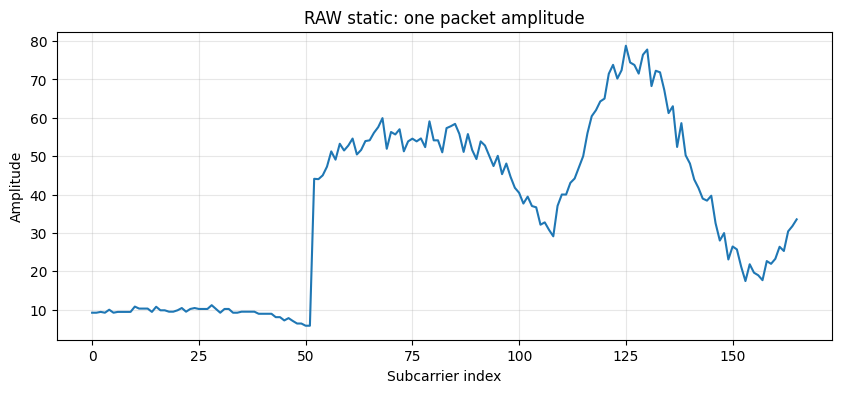

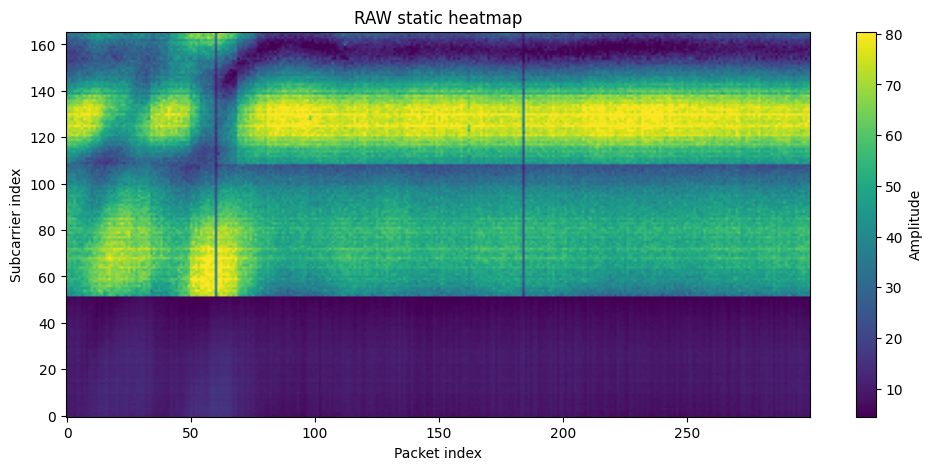

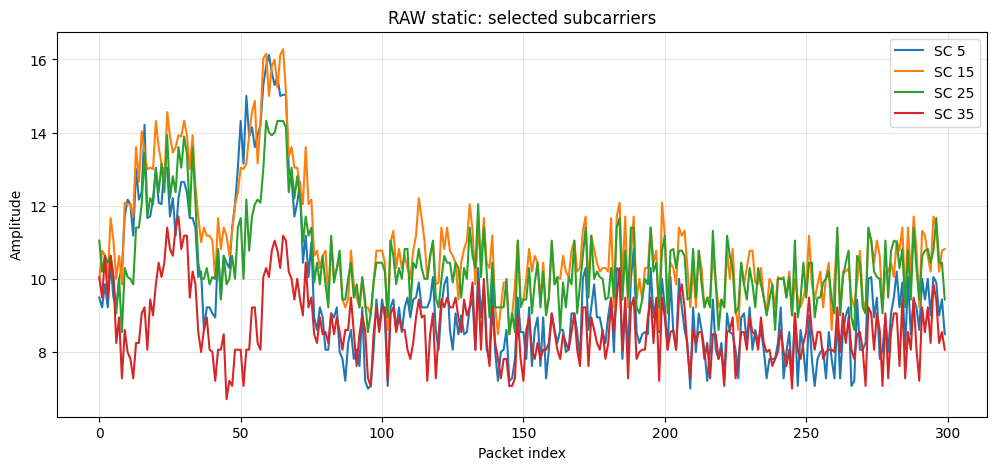

In [10]:
plot_packet_amplitude(A_static_raw, packet_idx=1, title='RAW static: one packet amplitude')
plot_heatmap(A_static_raw, max_packets=300, title='RAW static heatmap')
plot_subcarriers(A_static_raw, title='RAW static: selected subcarriers')


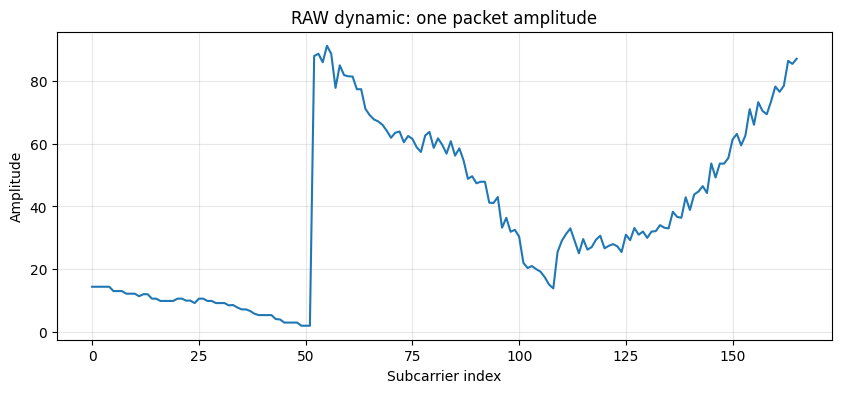

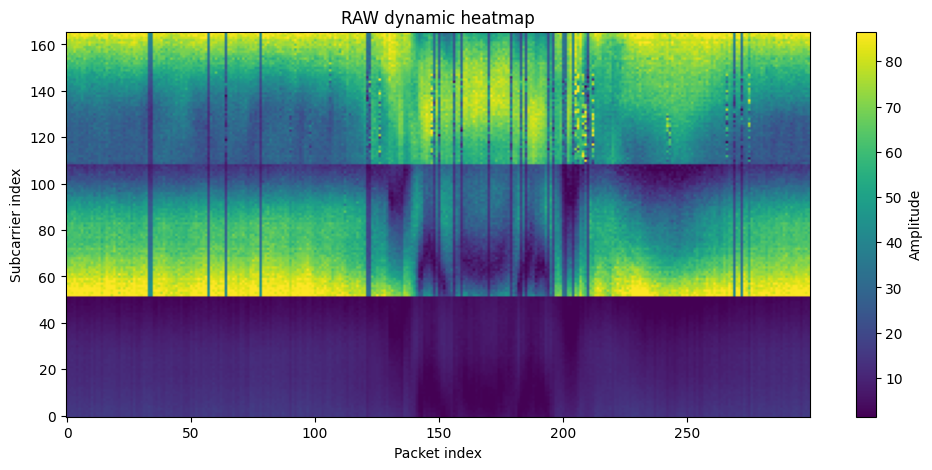

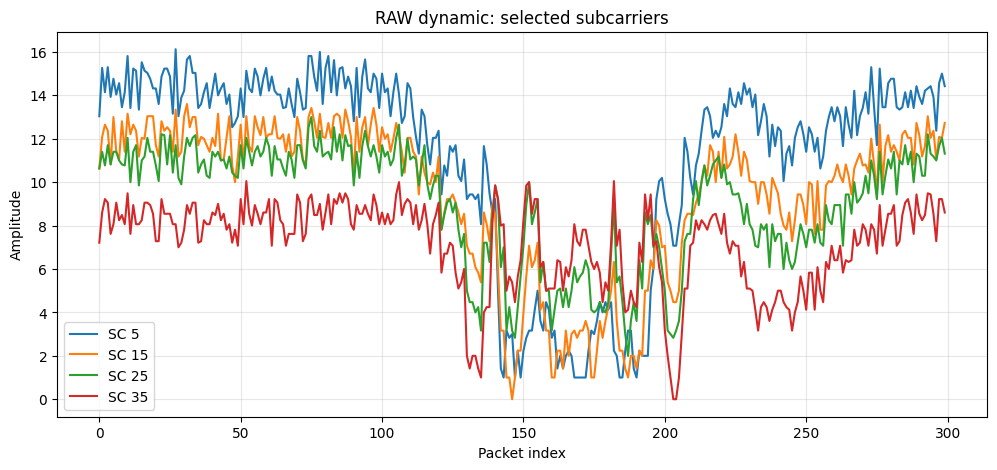

In [11]:
plot_packet_amplitude(A_dynamic_raw, packet_idx=0, title='RAW dynamic: one packet amplitude')
plot_heatmap(A_dynamic_raw, max_packets=300, title='RAW dynamic heatmap')
plot_subcarriers(A_dynamic_raw, title='RAW dynamic: selected subcarriers')


In [12]:
def animate_csi_spectrum(t, X_raw, X_proc, every_n=1, max_frames=200):
    """
    Анимация изменения CSI-вектора по поднесущим во времени.
    """
    idx = np.arange(0, len(X_raw), every_n)
    if len(idx) > max_frames:
        idx = idx[:max_frames]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sc_axis = np.arange(X_raw.shape[1])

    raw_min, raw_max = np.min(X_raw), np.max(X_raw)
    proc_min, proc_max = np.min(X_proc), np.max(X_proc)

    line_raw, = axes[0].plot(sc_axis, X_raw[idx[0]], lw=2)
    line_proc, = axes[1].plot(sc_axis, X_proc[idx[0]], lw=2)

    axes[0].set_title("RAW CSI amplitude")
    axes[0].set_xlabel("Subcarrier")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_ylim(raw_min, raw_max)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("PROCESSED CSI")
    axes[1].set_xlabel("Subcarrier")
    axes[1].set_ylabel("Processed value")
    axes[1].set_ylim(proc_min, proc_max)
    axes[1].grid(True, alpha=0.3)

    time_text = fig.suptitle("")

    def update(frame_i):
        k = idx[frame_i]
        line_raw.set_ydata(X_raw[k])
        line_proc.set_ydata(X_proc[k])

        if k < len(t):
            time_text.set_text(f"Packet {k} | time = {t[k]:.3f} s")
        else:
            time_text.set_text(f"Packet {k}")

        return line_raw, line_proc, time_text

    anim = FuncAnimation(fig, update, frames=len(idx), interval=120, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())


## 6. Preprocessing

В ноутбуке теперь есть три взаимозаменяемых preprocessing-пайплайна. Выбор делается в конфигурации через `PREPROCESSING_PIPELINE`.

### 6.1 `hampel_savgol`
1. **Hampel filter** убирает одиночные выбросы по времени в каждой поднесущей. Реализация оптимизирована через `scipy.ndimage.median_filter`.
2. **Savitzky-Golay** сглаживает сигнал по временной оси одним векторизованным вызовом `savgol_filter(..., axis=0)`.
3. **Rolling-mean detrend** убирает медленный фон / baseline:

$$
x_{\mathrm{detrended}}(t) = x(t) - \operatorname{rolling\_mean}(x(t))
$$

4. **Robust z-score** нормализует каждую поднесущую:

$$
z = \frac{x - \operatorname{median}(x)}{1.4826 \cdot \operatorname{MAD}(x)}
$$

### 6.2 `median`
1. **Median filter** по времени в каждой поднесущей подавляет короткие импульсные выбросы.
2. Затем применяются тот же **rolling-mean detrend** и тот же **robust z-score**.

### 6.3 `none`
Режим без preprocessing: в модель и графики передается **raw amplitude** как есть. Не выполняются filtering, detrending и robust z-score.

In [13]:
def valid_odd_window(n, requested_window, min_window=3):
    """
    Возвращает нечетный размер окна, не превышающий длину сигнала.
    """
    if n <= 1:
        return 1
    w = min(requested_window, n if n % 2 == 1 else n - 1)
    if w % 2 == 0:
        w -= 1
    return max(min_window, w)


def hampel_filter_matrix(A, window_size=7, n_sigma=3.0):
    """
    Быстрый Hampel-like filter для матрицы [T, S].
    Все rolling median/MAD считаются в scipy.ndimage.median_filter,
    без Python-цикла по packet/subcarrier.
    """
    X = np.asarray(A, dtype=np.float32)
    w = valid_odd_window(len(X), window_size, min_window=3)

    rolling_median = median_filter(X, size=(w, 1), mode='nearest')
    abs_dev = np.abs(X - rolling_median)
    rolling_mad = median_filter(abs_dev, size=(w, 1), mode='nearest')
    threshold = n_sigma * 1.4826 * (rolling_mad + 1e-8)

    return np.where(abs_dev > threshold, rolling_median, X).astype(np.float32)


def robust_zscore_per_subcarrier(X, scale_floor_percentile=10.0, clip=None):
    """
    Robust z-score по каждой поднесущей.

    Важная защита: если после detrend у канала почти нулевая MAD,
    обычное деление превращает численный шум в значения 1e6-1e7.
    Поэтому scale ограничивается снизу устойчивым floor по всем поднесущим.
    """
    X = np.asarray(X, dtype=np.float32)
    med = np.median(X, axis=0, keepdims=True)
    mad = np.median(np.abs(X - med), axis=0, keepdims=True)
    scale = 1.4826 * mad

    finite_scale = scale[np.isfinite(scale) & (scale > 0)]
    if finite_scale.size == 0:
        scale_floor = 1.0
    else:
        scale_floor = max(float(np.percentile(finite_scale, scale_floor_percentile)), 1e-6)

    scale = np.maximum(scale, scale_floor)
    Z = (X - med) / scale

    if clip is not None:
        Z = np.clip(Z, -clip, clip)

    return Z.astype(np.float32), med.astype(np.float32), scale.astype(np.float32), scale_floor


def valid_savgol_window(n, requested_window, polyorder):
    """
    Savitzky-Golay требует нечетное window_length и window_length > polyorder.
    """
    if n <= polyorder + 1:
        return None
    w = min(requested_window, n if n % 2 == 1 else n - 1)
    if w % 2 == 0:
        w -= 1
    min_w = polyorder + 2
    if min_w % 2 == 0:
        min_w += 1
    if w < min_w:
        return None
    return w


def detrend_and_normalize(
    X,
    detrend_window=51,
    scale_floor_percentile=10.0,
    z_clip=8.0,
):
    detrend_window = min(detrend_window, len(X))
    trend = uniform_filter1d(X, size=detrend_window, axis=0, mode='nearest')
    detrended = X - trend
    normalized, med, scale, scale_floor = robust_zscore_per_subcarrier(
        detrended,
        scale_floor_percentile=scale_floor_percentile,
        clip=z_clip,
    )
    return trend, detrended, normalized, med, scale, scale_floor


def preprocess_amplitude(
    A,
    hampel_window=7,
    hampel_sigma=3.0,
    sg_window=11,
    sg_poly=3,
    detrend_window=51,
    scale_floor_percentile=10.0,
    z_clip=8.0,
):
    """
    Hampel -> Savitzky-Golay -> detrend -> robust z-score.
    A: [T, S] raw amplitude
    returns dict with intermediate tensors
    """
    out = {'pipeline': 'hampel_savgol', 'raw': A.copy()}

    # 1) Vectorized Hampel per subcarrier/time window
    X1 = hampel_filter_matrix(A, window_size=hampel_window, n_sigma=hampel_sigma)
    out['hampel'] = X1

    # 2) Vectorized Savitzky-Golay along time axis
    w = valid_savgol_window(len(X1), sg_window, sg_poly)
    if w is None:
        X2 = X1.copy()
    else:
        X2 = savgol_filter(X1, window_length=w, polyorder=sg_poly, axis=0, mode='nearest').astype(np.float32)
    out['smoothed'] = X2

    # 3-4) Rolling mean detrend + robust z-score
    trend, detrended, normalized, med, scale, scale_floor = detrend_and_normalize(
        X2,
        detrend_window=detrend_window,
        scale_floor_percentile=scale_floor_percentile,
        z_clip=z_clip,
    )
    out['trend'] = trend
    out['detrended'] = detrended
    out['normalized'] = normalized
    out['normalization_median'] = med
    out['normalization_scale'] = scale
    out['normalization_scale_floor'] = scale_floor

    return out


def preprocess_amplitude_median(
    A,
    median_window=7,
    detrend_window=51,
    scale_floor_percentile=10.0,
    z_clip=8.0,
):
    """
    median filter -> detrend -> robust z-score.
    Median filter применяется только вдоль времени, отдельно для каждой поднесущей.
    """
    if median_window % 2 == 0:
        median_window += 1
    median_window = max(3, min(median_window, len(A) if len(A) % 2 == 1 else len(A) - 1))

    out = {'pipeline': 'median', 'raw': A.copy()}
    X1 = median_filter(A.astype(np.float32), size=(median_window, 1), mode='nearest')
    out['median_filtered'] = X1
    out['smoothed'] = X1

    trend, detrended, normalized, med, scale, scale_floor = detrend_and_normalize(
        X1,
        detrend_window=detrend_window,
        scale_floor_percentile=scale_floor_percentile,
        z_clip=z_clip,
    )
    out['trend'] = trend
    out['detrended'] = detrended
    out['normalized'] = normalized
    out['normalization_median'] = med
    out['normalization_scale'] = scale
    out['normalization_scale_floor'] = scale_floor

    return out


def preprocess_amplitude_none(A):
    """
    No preprocessing: raw amplitude без filtering, detrending и normalization.
    Ключ 'normalized' оставлен для совместимости с downstream-кодом.
    """
    X = A.astype(np.float32).copy()
    return {
        'pipeline': 'none',
        'raw': X.copy(),
        'smoothed': X.copy(),
        'trend': np.zeros_like(X, dtype=np.float32),
        'detrended': X.copy(),
        'normalized': X,
        'normalization_median': np.zeros((1, X.shape[1]), dtype=np.float32),
        'normalization_scale': np.ones((1, X.shape[1]), dtype=np.float32),
        'normalization_scale_floor': 1.0,
    }


def preprocess_csi_amplitude(A, pipeline=None, **kwargs):
    pipeline = pipeline or PREPROCESSING_PIPELINE
    if pipeline == 'hampel_savgol':
        return preprocess_amplitude(A, **kwargs)
    if pipeline == 'median':
        return preprocess_amplitude_median(A, **kwargs)
    if pipeline in ('none', 'raw'):
        return preprocess_amplitude_none(A)
    raise ValueError("Unknown preprocessing pipeline. Use 'hampel_savgol', 'median', or 'none'.")


def motion_energy(amplitude_like):
    """
    Простой индикатор динамики:
    среднее |dx/dt| по всем поднесущим.
    На вход лучше подавать данные в сопоставимой шкале, например robust z-score.
    """
    d = np.diff(amplitude_like, axis=0)
    return np.mean(np.abs(d), axis=1)


def print_preprocess_diagnostics(name, proc):
    X = proc['normalized']
    scale = proc['normalization_scale'].ravel()
    print(
        f"{name} [{proc['pipeline']}]: normalized min/max = {X.min():.3f}/{X.max():.3f}; "
        f"scale floor = {proc['normalization_scale_floor']:.6f}; "
        f"scale percentiles = {np.percentile(scale, [0, 10, 50, 90]).round(4)}"
    )


In [14]:
static_proc = preprocess_csi_amplitude(A_static_raw)
dynamic_proc = preprocess_csi_amplitude(A_dynamic_raw)

A_static_proc = static_proc['normalized']
A_dynamic_proc = dynamic_proc['normalized']

print_preprocess_diagnostics('static', static_proc)
print_preprocess_diagnostics('dynamic', dynamic_proc)


static [hampel_savgol]: normalized min/max = -8.000/8.000; scale floor = 0.380410; scale percentiles = [0.3804 0.381  1.7271 2.2831]
dynamic [hampel_savgol]: normalized min/max = -8.000/7.829; scale floor = 0.513575; scale percentiles = [0.5136 0.5142 2.3951 3.2057]


## 7. Визуализация обработанного сигнала


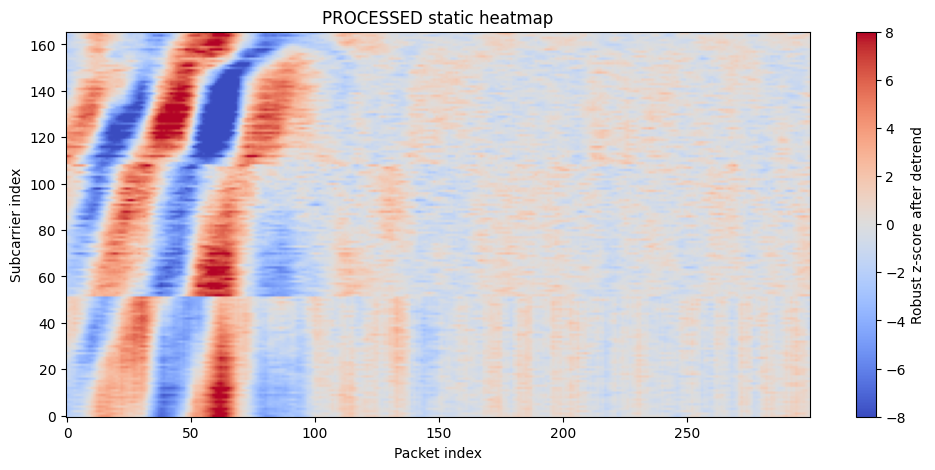

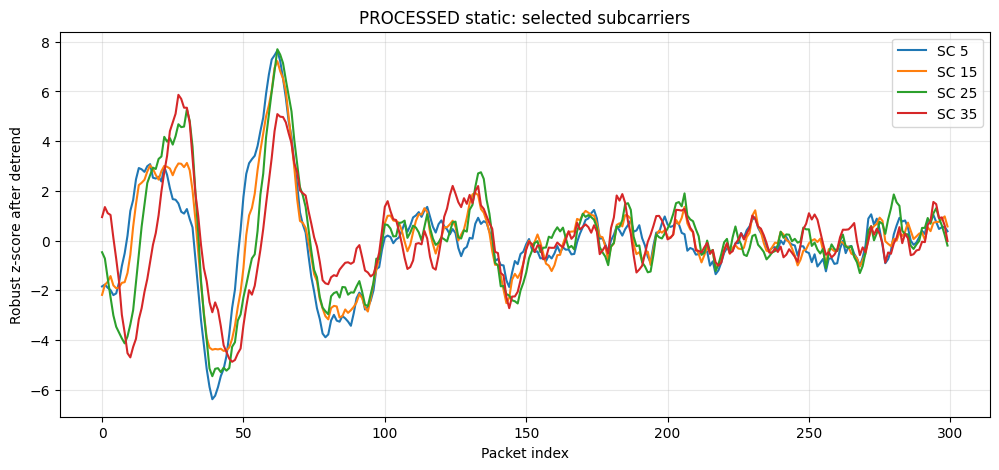

In [15]:
plot_processed_heatmap(static_proc, max_packets=300, title='PROCESSED static heatmap')
plot_processed_subcarriers(static_proc, title='PROCESSED static: selected subcarriers')


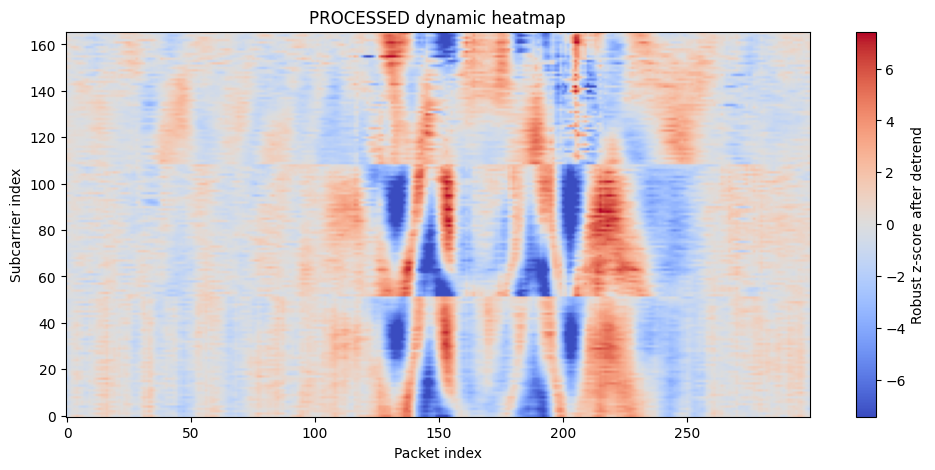

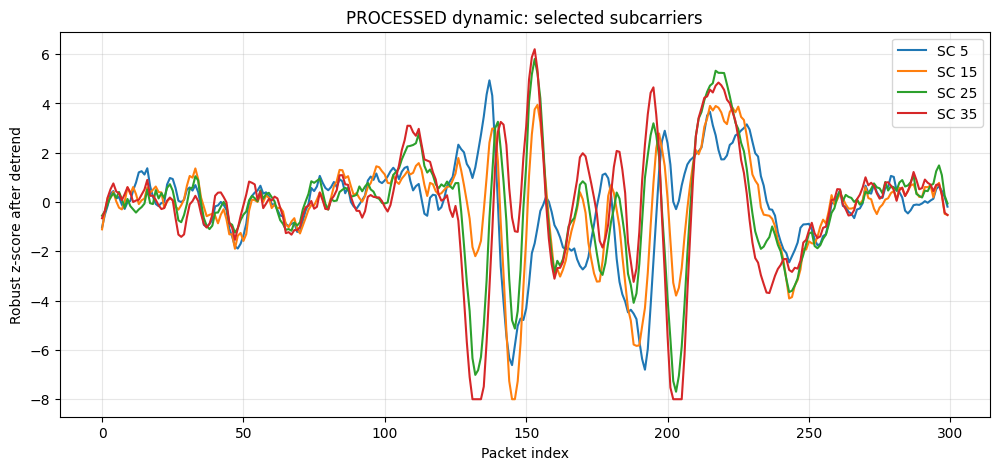

In [16]:
plot_processed_heatmap(dynamic_proc, max_packets=300, title='PROCESSED dynamic heatmap')
plot_processed_subcarriers(dynamic_proc, title='PROCESSED dynamic: selected subcarriers')


## 8. Сравнение raw vs processed на одних и тех же поднесущих


In [17]:
def standardize_for_plot(A):
    Z, _, _, _ = robust_zscore_per_subcarrier(A, scale_floor_percentile=10.0, clip=8.0)
    return Z


def compare_raw_processed(A_raw, A_proc, subcarriers=(5, 15, 25, 35), max_packets=300, title=''):
    """
    Для обычных preprocessing-пайплайнов сравниваем raw и processed в robust-z шкале.
    Для PREPROCESSING_PIPELINE='none' сравниваем raw amplitude с raw amplitude без смены единиц.
    """
    T = min(max_packets, len(A_raw), len(A_proc))
    is_none = PREPROCESSING_PIPELINE in ('none', 'raw')

    if is_none:
        raw_plot = A_raw
        proc_plot = A_proc
        raw_label = 'raw amplitude'
        proc_label = 'no preprocessing amplitude'
        ylim = None
    else:
        raw_plot = standardize_for_plot(A_raw)
        proc_plot = A_proc
        raw_label = 'raw amplitude (robust z)'
        proc_label = 'processed detrended (robust z)'
        ylim = (-8.5, 8.5)

    plt.figure(figsize=(13, 8))

    for i, sc in enumerate(subcarriers, start=1):
        if sc >= A_raw.shape[1] or sc >= A_proc.shape[1]:
            continue
        plt.subplot(len(subcarriers), 1, i)
        plt.plot(raw_plot[:T, sc], label=raw_label, alpha=0.75)
        plt.plot(proc_plot[:T, sc], label=proc_label, alpha=0.9)
        plt.ylabel(f'SC {sc}')
        if ylim is not None:
            plt.ylim(*ylim)
        plt.grid(alpha=0.3)
        if i == 1:
            plt.title(title)
            plt.legend(loc='upper right')

    plt.xlabel('Packet index')
    plt.tight_layout()
    plt.show()


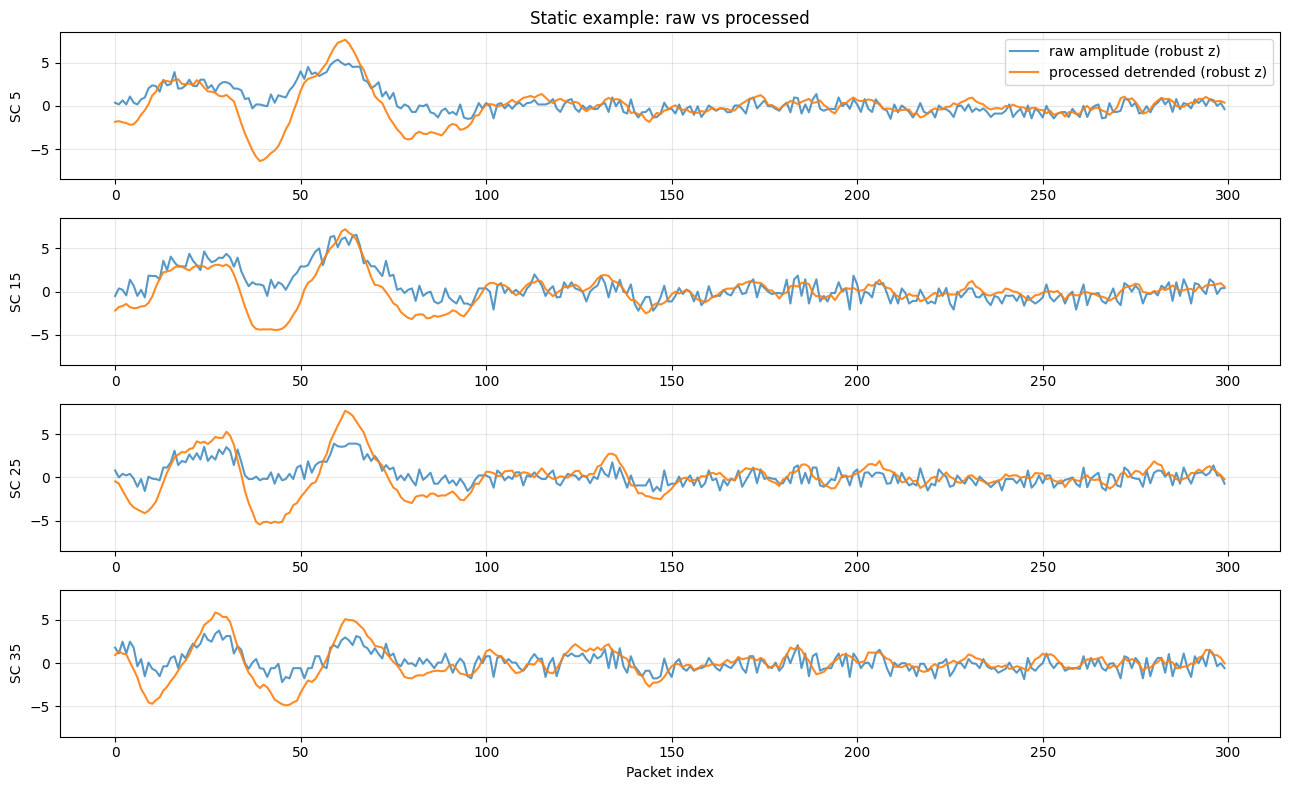

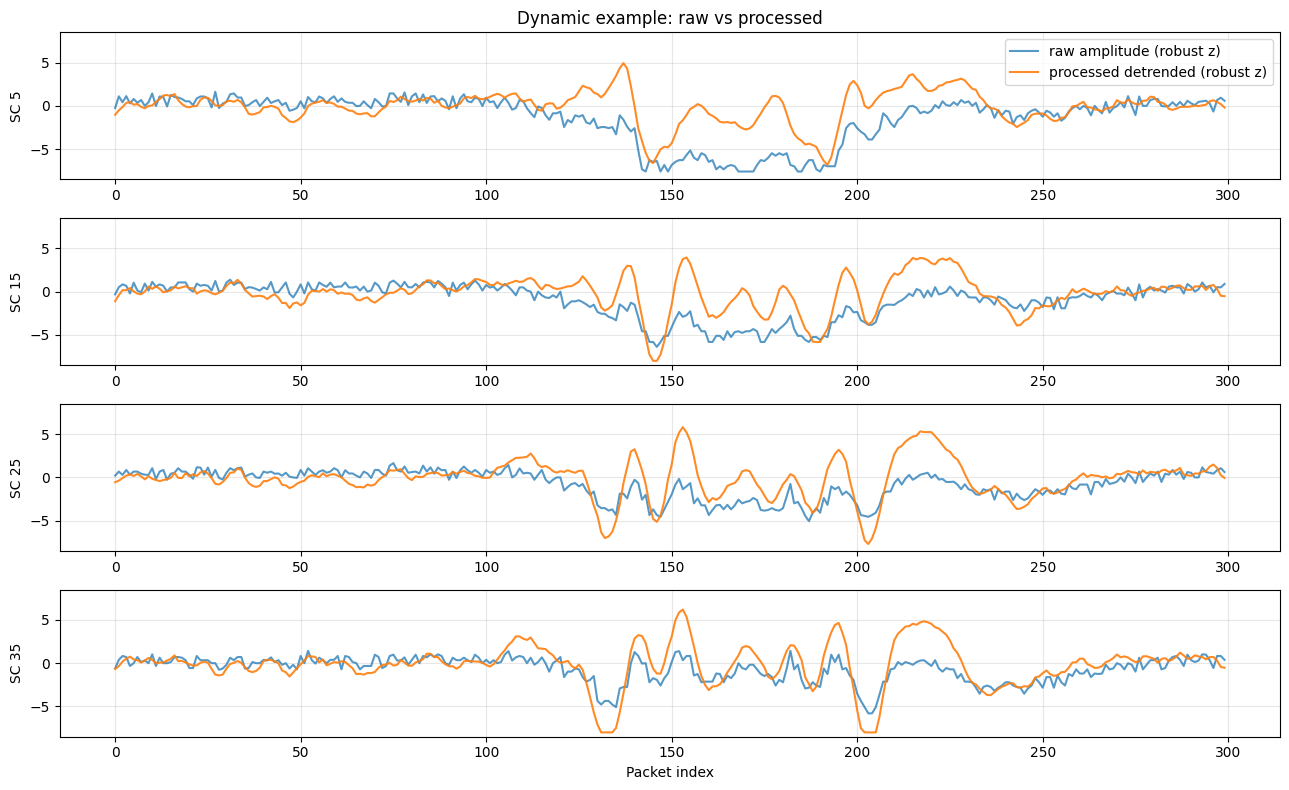

In [18]:
compare_raw_processed(
    A_static_raw,
    A_static_proc,
    title='Static example: raw vs processed'
)

compare_raw_processed(
    A_dynamic_raw,
    A_dynamic_proc,
    title='Dynamic example: raw vs processed'
)


## 9. Motion energy до и после preprocessing


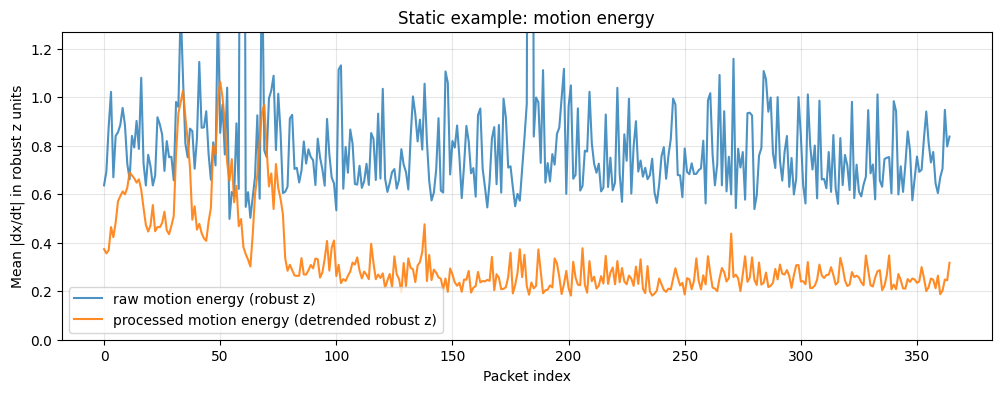

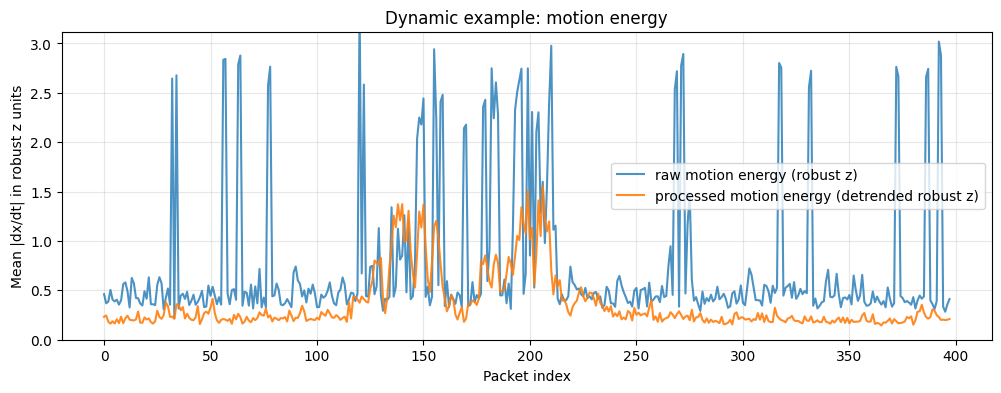

In [19]:
def plot_motion_energy(raw, proc, title=''):
    is_none = PREPROCESSING_PIPELINE in ('none', 'raw')

    if is_none:
        e_raw = motion_energy(raw)
        e_proc = motion_energy(proc)
        raw_label = 'raw motion energy'
        proc_label = 'no preprocessing motion energy'
        ylabel = 'Mean |dx/dt| in amplitude units'
    else:
        # raw amplitude и processed z-score нельзя честно сравнивать как есть.
        # Поэтому raw тоже переводим в robust z-score.
        raw_z = standardize_for_plot(raw)
        e_raw = motion_energy(raw_z)
        e_proc = motion_energy(proc)
        raw_label = 'raw motion energy (robust z)'
        proc_label = 'processed motion energy (detrended robust z)'
        ylabel = 'Mean |dx/dt| in robust z units'

    ymax = np.percentile(np.r_[e_raw, e_proc], 99)
    ymax = max(float(ymax) * 1.1, 1e-6)

    plt.figure(figsize=(12, 4))
    plt.plot(e_raw, label=raw_label, alpha=0.8)
    plt.plot(e_proc, label=proc_label, alpha=0.9)
    plt.title(title)
    plt.xlabel('Packet index')
    plt.ylabel(ylabel)
    plt.ylim(0, ymax)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_motion_energy(A_static_raw, A_static_proc, title='Static example: motion energy')
plot_motion_energy(A_dynamic_raw, A_dynamic_proc, title='Dynamic example: motion energy')


## 10. Бинарная задача `static / dynamic macro motion`

Метки:
- `0` = **static**: `nopeople` и `standing`;
- `1` = **dynamic macro**: крупные движения тела.

`ML_MAX_FILES_PER_CLASS` означает количество CSV-файлов **на бинарный класс**, а не на каждый исходный activity label.


In [20]:
STATIC_CLASSES = ('nopeople', 'standing')
DYNAMIC_MACRO_CLASSES = ('jump', 'punching', 'pushpull', 'squatting', 'twist', 'waving')
DYNAMIC_MICRO_EXCLUDED = ('clap', 'rubhand')

BINARY_CLASS_LABELS = {
    0: STATIC_CLASSES,
    1: DYNAMIC_MACRO_CLASSES,
}

ALL_CLASSES = sorted([p.name for p in (RAW_ROOT / 'front').iterdir() if p.is_dir()])


def class_to_binary(label: str) -> int:
    if label in STATIC_CLASSES:
        return 0
    if label in DYNAMIC_MACRO_CLASSES:
        return 1
    raise ValueError(f'Class {label!r} is not used in the binary static/dynamic-macro setup.')


def segment_array(X, window=200, step=100):
    segments = []
    if len(X) < window:
        return segments
    for start in range(0, len(X) - window + 1, step):
        segments.append(X[start:start + window])
    return segments


def collect_files_for_labels(root, view, labels):
    files_by_label = {}
    for label in labels:
        folder = root / view / label
        files = sorted(folder.glob('*.csv'))
        if len(files) == 0:
            print(f'Warning: no files found for {folder}')
        files_by_label[label] = files
    return files_by_label


def select_files_for_binary_class(files_by_label, max_files_per_class=None, random_state=42):
    """
    Выбирает до max_files_per_class файлов суммарно на бинарный класс.
    Файлы распределяются по исходным activity labels примерно равномерно.
    """
    labels = list(files_by_label)
    if max_files_per_class is None:
        return [(label, fp) for label in labels for fp in files_by_label[label]]

    rng = np.random.default_rng(random_state)
    shuffled = {}
    for label in labels:
        files = np.asarray(files_by_label[label], dtype=object)
        if len(files):
            files = files[rng.permutation(len(files))]
        shuffled[label] = list(files)

    selected = []
    cursor = {label: 0 for label in labels}
    while len(selected) < max_files_per_class:
        added_on_round = False
        for label in labels:
            i = cursor[label]
            if i < len(shuffled[label]) and len(selected) < max_files_per_class:
                selected.append((label, shuffled[label][i]))
                cursor[label] += 1
                added_on_round = True
        if not added_on_round:
            break

    return selected


def build_binary_windows(
    root=RAW_ROOT,
    view='front',
    max_files_per_class=None,
    window=200,
    step=100,
    random_state=42,
):
    """
    Возвращает:
    - X: [N, T, S] processed CSI windows
    - y: [N] binary labels: 0=static, 1=dynamic macro
    - groups: [N] path к исходному CSV, нужен для честного split по файлам
    - window_labels: [N] исходный activity label

    max_files_per_class относится к бинарным классам static/dynamic,
    а не к каждому исходному activity label.
    """
    X_list = []
    y_list = []
    groups = []
    window_labels = []
    selected_file_rows = []

    for binary_label, source_labels in BINARY_CLASS_LABELS.items():
        files_by_label = collect_files_for_labels(root, view, source_labels)
        selected_files = select_files_for_binary_class(
            files_by_label,
            max_files_per_class=max_files_per_class,
            random_state=random_state + binary_label,
        )

        for label, fp in selected_files:
            selected_file_rows.append({
                'binary_label': binary_label,
                'binary_name': 'static' if binary_label == 0 else 'dynamic_macro',
                'activity': label,
                'file': str(fp),
            })

            try:
                parser = ESP32CSIParser(fp).parse_all(sig_mode=1)
                A = parser.amplitude
                P = preprocess_csi_amplitude(A)['normalized']
                segs = segment_array(P, window=window, step=step)

                for seg in segs:
                    X_list.append(seg.astype(np.float32))
                    y_list.append(binary_label)
                    groups.append(str(fp))
                    window_labels.append(label)
            except Exception as e:
                print(f'Skip {fp.name}: {e}')

    if not X_list:
        raise ValueError('Не удалось собрать ни одного окна. Проверь root/view/window/max_files_per_class.')

    X = np.stack(X_list)   # [N, T, S]
    y = np.asarray(y_list, dtype=np.int64)
    groups = np.asarray(groups)
    window_labels = np.asarray(window_labels)
    selected_files_df = pd.DataFrame(selected_file_rows)

    return X, y, groups, window_labels, selected_files_df


In [21]:
# Маленький поднабор для быстрой проверки пайплайна.
# ML_MAX_FILES_PER_CLASS задает число файлов на бинарный класс:
# до N static-файлов суммарно и до N dynamic-macro-файлов суммарно.
ML_VIEW = 'front'
ML_MAX_FILES_PER_CLASS = 2000
ML_WINDOW = 200
ML_STEP = 100

# Набор признаков для ML:
# - 'motion_only': только признаки изменения во времени; честнее для сравнения preprocessing
# - 'all': все признаки, включая абсолютный профиль канала
# - 'absolute_only': диагностический режим, показывает, насколько модель опирается на baseline
FEATURE_SET = 'motion_only'

X_bin, y_bin, groups_bin, activity_bin, selected_files_df = build_binary_windows(
    view=ML_VIEW,
    max_files_per_class=ML_MAX_FILES_PER_CLASS,
    window=ML_WINDOW,
    step=ML_STEP,
    random_state=42,
)

print('Selected files by binary class:')
print(selected_files_df.groupby(['binary_name', 'activity']).size())
print('\nSelected files total:')
print(selected_files_df['binary_name'].value_counts())

print('\nX:', X_bin.shape)
print('y:', y_bin.shape)
print('groups:', groups_bin.shape)
print('Window balance [static, dynamic_macro]:', np.bincount(y_bin, minlength=2))
print('Unique source files:', len(np.unique(groups_bin)))
print('\nWindow activities:')
print(pd.Series(activity_bin).value_counts().sort_index())


Selected files by binary class:
binary_name    activity 
dynamic_macro  jump          334
               punching      334
               pushpull      333
               squatting     333
               twist         333
               waving        333
static         nopeople     1000
               standing     1000
dtype: int64

Selected files total:
binary_name
static           2000
dynamic_macro    2000
Name: count, dtype: int64

X: (9543, 200, 166)
y: (9543,)
groups: (9543,)
Window balance [static, dynamic_macro]: [4637 4906]
Unique source files: 3991

Window activities:
jump          857
nopeople     2359
punching      841
pushpull      774
squatting     799
standing     2278
twist         805
waving        830
Name: count, dtype: int64


## 11. Классический ML-классификатор

Превращаем каждое окно `[time, subcarrier]` в табличный вектор признаков и обучаем классические модели.

Важный переключатель: `FEATURE_SET`.
- `motion_only` — признаки динамики: временная производная, `motion_energy`, энергия изменений по поднесущим и по времени. Это основной режим для сравнения preprocessing-пайплайнов.
- `all` — все признаки, включая абсолютный уровень/профиль CSI. На raw amplitude этот режим может давать завышенные метрики, потому что модель частично узнает условия записи, а не само движение.
- `absolute_only` — диагностический режим: оставляет только baseline/профиль канала.

Все доступные признаки:
- `x_*` — статистики значений окна;
- `abs_x_*` — статистики абсолютных значений окна;
- `dt_*` — статистики временной производной `diff`;
- `abs_dt_*` — статистики модуля временной производной;
- `motion_energy_*` — статистики среднего `|dx/dt|` по поднесущим;
- `sc_mean_###`, `sc_std_###`, `sc_energy_###` — среднее/std/энергия изменений для каждой поднесущей;
- `t_mean_###`, `t_std_###`, `t_energy_###` — среднее/std/энергия изменений для каждого packet внутри окна.

Оценка делается через `GroupShuffleSplit`, где group = исходный CSV-файл. Это защищает от ситуации, когда соседние окна одного файла попали и в train, и в test.


In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def summarize_vector(v, prefix):
    v = np.asarray(v, dtype=np.float32)
    return {
        f'{prefix}_mean': float(np.mean(v)),
        f'{prefix}_std': float(np.std(v)),
        f'{prefix}_min': float(np.min(v)),
        f'{prefix}_p10': float(np.percentile(v, 10)),
        f'{prefix}_median': float(np.median(v)),
        f'{prefix}_p90': float(np.percentile(v, 90)),
        f'{prefix}_max': float(np.max(v)),
    }


def extract_csi_features(X):
    """
    X: [N, T, S] processed CSI windows.
    Возвращает DataFrame с табличными признаками для классического ML.
    """
    rows = []

    for window in X:
        d_time = np.diff(window, axis=0)
        abs_window = np.abs(window)
        abs_d_time = np.abs(d_time)
        motion_e = np.mean(abs_d_time, axis=1)

        feats = {}
        feats.update(summarize_vector(window.ravel(), 'x'))
        feats.update(summarize_vector(abs_window.ravel(), 'abs_x'))
        feats.update(summarize_vector(d_time.ravel(), 'dt'))
        feats.update(summarize_vector(abs_d_time.ravel(), 'abs_dt'))
        feats.update(summarize_vector(motion_e, 'motion_energy'))

        # Per-subcarrier summaries preserve frequency/subcarrier structure.
        sc_mean = np.mean(window, axis=0)
        sc_std = np.std(window, axis=0)
        sc_energy = np.mean(abs_d_time, axis=0)

        for i, value in enumerate(sc_mean):
            feats[f'sc_mean_{i:03d}'] = float(value)
        for i, value in enumerate(sc_std):
            feats[f'sc_std_{i:03d}'] = float(value)
        for i, value in enumerate(sc_energy):
            feats[f'sc_energy_{i:03d}'] = float(value)

        # Time summaries preserve rough temporal shape of the window.
        t_mean = np.mean(window, axis=1)
        t_std = np.std(window, axis=1)
        t_energy = np.r_[motion_e, motion_e[-1]] if len(motion_e) else np.zeros(len(window), dtype=np.float32)

        for i, value in enumerate(t_mean):
            feats[f't_mean_{i:03d}'] = float(value)
        for i, value in enumerate(t_std):
            feats[f't_std_{i:03d}'] = float(value)
        for i, value in enumerate(t_energy):
            feats[f't_energy_{i:03d}'] = float(value)

        rows.append(feats)

    return pd.DataFrame(rows).astype(np.float32)


FEATURE_PREFIXES = {
    'motion_only': ('dt_', 'abs_dt_', 'motion_energy_', 'sc_energy_', 't_energy_'),
    'absolute_only': ('x_', 'abs_x_', 'sc_mean_', 'sc_std_', 't_mean_', 't_std_'),
}


def select_feature_columns(features, feature_set='motion_only'):
    if feature_set == 'all':
        return list(features.columns)
    if feature_set in FEATURE_PREFIXES:
        prefixes = FEATURE_PREFIXES[feature_set]
        cols = [c for c in features.columns if c.startswith(prefixes)]
        if not cols:
            raise ValueError(f'FEATURE_SET={feature_set!r} selected zero columns.')
        return cols
    raise ValueError("Unknown FEATURE_SET. Use 'motion_only', 'all', or 'absolute_only'.")


features_bin = extract_csi_features(X_bin)
selected_feature_columns = select_feature_columns(features_bin, FEATURE_SET)
features_ml = features_bin[selected_feature_columns]

print('Feature table, all:', features_bin.shape)
print(f'FEATURE_SET = {FEATURE_SET!r}')
print('Feature table, selected:', features_ml.shape)
features_ml.head()


Feature table, all: (9543, 1133)
FEATURE_SET = 'motion_only'
Feature table, selected: (9543, 387)


,dt_mean,dt_std,dt_min,dt_p10,dt_median,dt_p90,dt_max,abs_dt_mean,abs_dt_std,abs_dt_min,...,t_energy_190,t_energy_191,t_energy_192,t_energy_193,t_energy_194,t_energy_195,t_energy_196,t_energy_197,t_energy_198,t_energy_199
0,-0.000416,0.503457,-2.159712,-0.637482,-0.000920,0.637395,2.335553,0.399900,0.305858,0.000000,...,0.308815,0.509785,0.491254,0.404398,0.364257,0.356367,0.378312,0.369258,0.406827,0.406827
1,-0.000256,0.504589,-2.159712,-0.636349,-0.000206,0.637737,2.551825,0.398827,0.309106,0.000000,...,0.438824,0.488404,0.340854,0.492373,0.415757,0.340222,0.406950,0.402107,0.358996,0.358996
2,-0.002329,0.509082,-2.110024,-0.646235,0.000014,0.641212,2.551825,0.402148,0.312164,0.000005,...,0.506510,0.399349,0.406585,0.404629,0.379412,0.496124,0.357209,0.364161,0.353253,0.353253
3,-0.000768,0.502815,-2.184829,-0.644167,-0.003962,0.637381,2.135357,0.399035,0.305932,0.000009,...,0.374166,0.304944,0.407055,0.325681,0.383323,0.455345,0.327495,0.493201,0.384687,0.384687
4,-0.001049,0.485464,-1.983624,-0.624549,-0.004445,0.619500,2.026129,0.385959,0.294469,0.000009,...,0.409467,0.357092,0.351836,0.393514,0.405311,0.468485,0.346408,0.372839,0.349500,0.349500


## 12. Train/test split по файлам


In [23]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(features_ml, y_bin, groups=groups_bin))

X_train = features_ml.iloc[train_idx]
X_test = features_ml.iloc[test_idx]
y_train = y_bin[train_idx]
y_test = y_bin[test_idx]
groups_train = groups_bin[train_idx]
groups_test = groups_bin[test_idx]
activity_train = activity_bin[train_idx]
activity_test = activity_bin[test_idx]

print('Train windows:', X_train.shape[0], 'Test windows:', X_test.shape[0])
print('Train source files:', len(np.unique(groups_train)), 'Test source files:', len(np.unique(groups_test)))
print('Train balance [static, dynamic_macro]:', np.bincount(y_train, minlength=2))
print('Test balance  [static, dynamic_macro]:', np.bincount(y_test, minlength=2))
print('Test activities:')
print(pd.Series(activity_test).value_counts().sort_index())


Train windows: 6661 Test windows: 2882
Train source files: 2793 Test source files: 1198
Train balance [static, dynamic_macro]: [3265 3396]
Test balance  [static, dynamic_macro]: [1372 1510]
Test activities:
jump         302
nopeople     715
punching     249
pushpull     220
squatting    225
standing     657
twist        255
waving       259
Name: count, dtype: int64


## 13. Обучение классических моделей

Сравниваем:
- `DummyClassifier` как sanity-check baseline;
- `LogisticRegression` как простой линейный классификатор;
- `RandomForestClassifier` как нелинейный классический ML baseline;
- `SVC` с RBF-kernel как SVM baseline.


In [24]:
models = {
    'dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
    'logreg_balanced': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42,
        )),
    ]),
    'random_forest_balanced': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'svm_rbf_balanced': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=42,
        )),
    ]),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f'fit: {name}')


fit: dummy_most_frequent
fit: logreg_balanced
fit: random_forest_balanced
fit: svm_rbf_balanced


## 14. Метрики

Для текущей задачи особенно полезны:
- `balanced_accuracy`, потому что классы могут быть не идеально сбалансированы;
- `f1_motion`, потому что класс `dynamic_macro` обычно главный;
- `recall_no_motion`, чтобы видеть, не принимает ли модель покой за движение;
- confusion matrix.


In [25]:
def predict_positive_score(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        score = model.decision_function(X)
        return (score - score.min()) / (score.max() - score.min() + 1e-8)
    return None


def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )
    score = predict_positive_score(model, X_test)
    auc = np.nan
    if score is not None and len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, score)

    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'precision_no_motion': precision[0],
        'recall_no_motion': recall[0],
        'f1_no_motion': f1[0],
        'precision_motion': precision[1],
        'recall_motion': recall[1],
        'f1_motion': f1[1],
        'roc_auc': auc,
        'support_no_motion': support[0],
        'support_motion': support[1],
    }


metrics_df = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in fitted_models.items()
]).sort_values('balanced_accuracy', ascending=False)

metrics_df


,model,accuracy,balanced_accuracy,precision_no_motion,recall_no_motion,f1_no_motion,precision_motion,recall_motion,f1_motion,roc_auc,support_no_motion,support_motion
2,random_forest_balanced,0.935461,0.933282,0.974400,0.887755,0.929062,0.905637,0.978808,0.940802,0.975148,1372,1510
3,svm_rbf_balanced,0.930257,0.928814,0.952124,0.898688,0.924634,0.912413,0.958940,0.935098,0.974060,1372,1510
1,logreg_balanced,0.915337,0.915342,0.907514,0.915452,0.911466,0.922563,0.915232,0.918883,0.961902,1372,1510
0,dummy_most_frequent,0.523942,0.500000,0.000000,0.000000,0.000000,0.523942,1.000000,0.687614,0.500000,1372,1510


Best model: random_forest_balanced
               precision    recall  f1-score   support

       static       0.97      0.89      0.93      1372
dynamic_macro       0.91      0.98      0.94      1510

     accuracy                           0.94      2882
    macro avg       0.94      0.93      0.93      2882
 weighted avg       0.94      0.94      0.94      2882



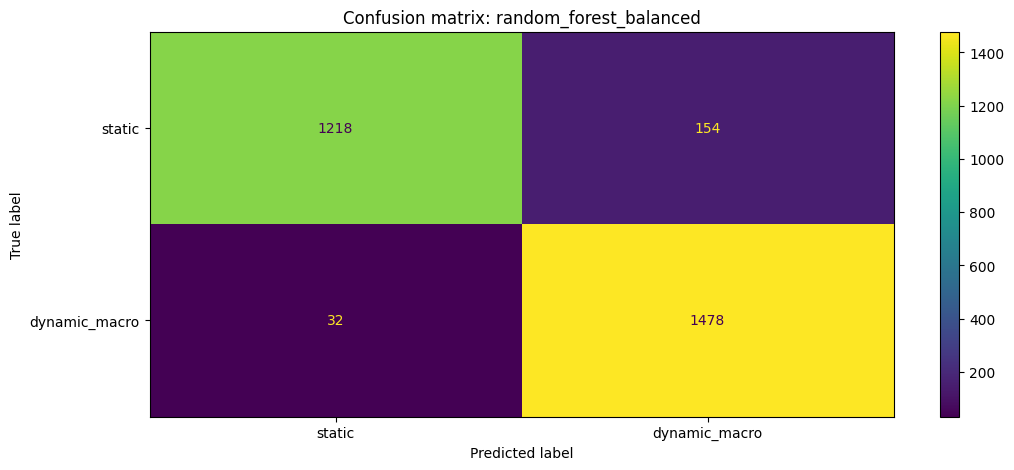

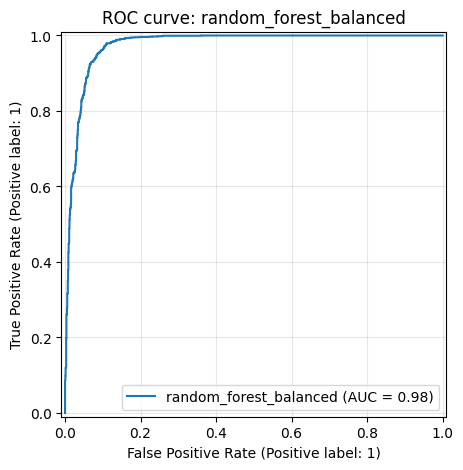

In [26]:
BEST_MODEL_NAME = metrics_df.iloc[0]['model']
best_model = fitted_models[BEST_MODEL_NAME]
y_pred = best_model.predict(X_test)

print('Best model:', BEST_MODEL_NAME)
print(classification_report(
    y_test,
    y_pred,
    target_names=['static', 'dynamic_macro'],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['static', 'dynamic_macro']).plot(values_format='d')
plt.title(f'Confusion matrix: {BEST_MODEL_NAME}')
plt.grid(False)
plt.show()

score = predict_positive_score(best_model, X_test)
if score is not None and len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, score, name=BEST_MODEL_NAME)
    plt.title(f'ROC curve: {BEST_MODEL_NAME}')
    plt.grid(alpha=0.3)
    plt.show()


## 15. Feature importance для `RandomForestClassifier`


,feature,importance
16,motion_energy_min,0.076484
17,motion_energy_p10,0.071427
15,motion_energy_std,0.047877
18,motion_energy_median,0.037698
10,abs_dt_p10,0.023343
20,motion_energy_max,0.020659
380,t_energy_193,0.014545
376,t_energy_189,0.014002
385,t_energy_198,0.013932
11,abs_dt_median,0.013331


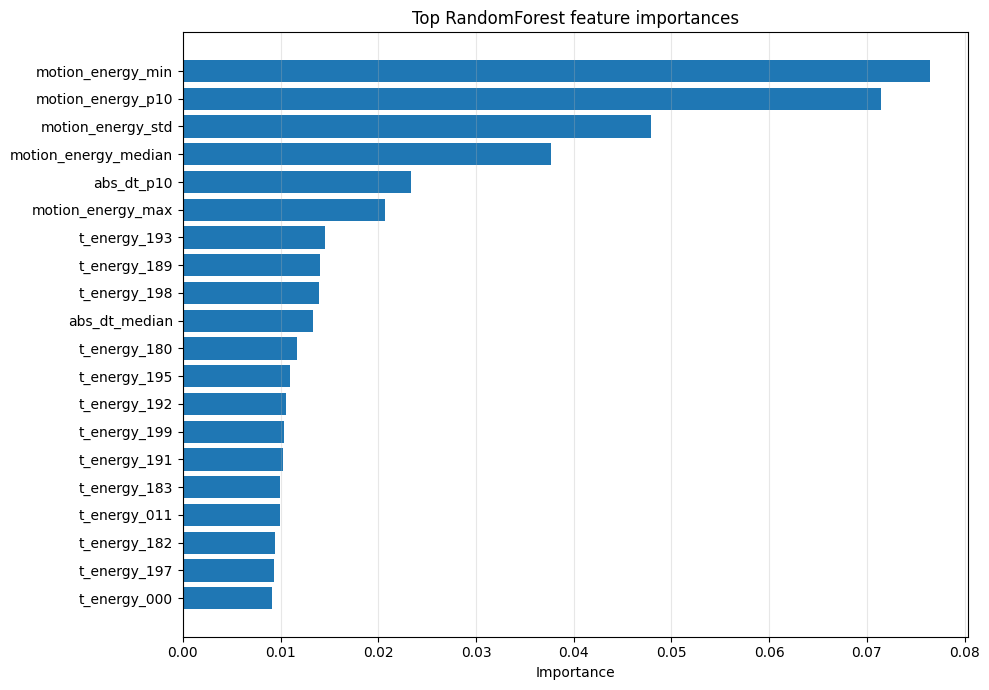

In [27]:
rf = fitted_models.get('random_forest_balanced')
if rf is not None and hasattr(rf, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': features_ml.columns,
        'importance': rf.feature_importances_,
    }).sort_values('importance', ascending=False)

    display(importance_df.head(30))

    top = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(top['feature'], top['importance'])
    plt.title('Top RandomForest feature importances')
    plt.xlabel('Importance')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
